# Data Mining Project
## Obesity Level Prediction using Machine Learning

**Name:** Sachpreet Singh  
**Roll No.:** 11519051624

**Batch&Semester:** AIML- 4rth Sem

**Submitted To:** Dr. Amit Choudhary

In [2]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Load Dataset

In [4]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

print("Shape of Dataset:", df.shape)
df.head()

Shape of Dataset: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# Dataset Info

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


# Data Visualization

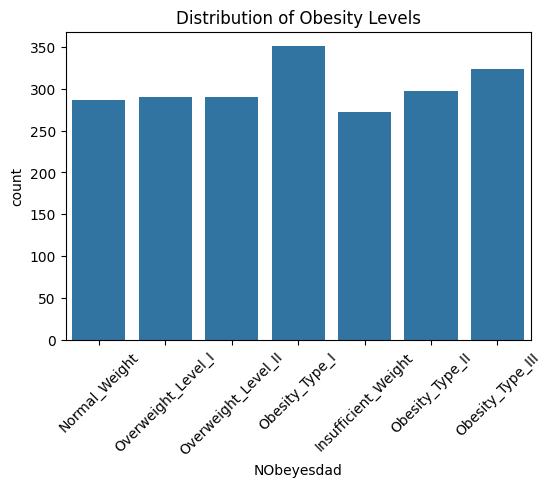

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["NObeyesdad"])
plt.title("Distribution of Obesity Levels")
plt.xticks(rotation=45)
plt.show()

# Data Preprocessing

In [9]:
# Encoding categorical variables
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Splitting features and target
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Classification Section 

# 1. Logistic Regression

In [10]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8747044917257684
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        56
           1       0.91      0.63      0.74        62
           2       0.93      0.90      0.92        78
           3       0.89      0.97      0.93        58
           4       1.00      1.00      1.00        63
           5       0.77      0.79      0.78        56
           6       0.76      0.84      0.80        50

    accuracy                           0.87       423
   macro avg       0.87      0.87      0.87       423
weighted avg       0.88      0.87      0.87       423



# 2. Decision Tree

In [11]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9314420803782506
              precision    recall  f1-score   support

           0       0.93      0.96      0.95        56
           1       0.86      0.87      0.86        62
           2       0.96      0.91      0.93        78
           3       0.93      0.95      0.94        58
           4       1.00      1.00      1.00        63
           5       0.88      0.89      0.88        56
           6       0.96      0.94      0.95        50

    accuracy                           0.93       423
   macro avg       0.93      0.93      0.93       423
weighted avg       0.93      0.93      0.93       423



# 3. Random Forest

In [12]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9479905437352246
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        56
           1       0.89      0.87      0.88        62
           2       0.99      0.96      0.97        78
           3       0.97      0.98      0.97        58
           4       1.00      1.00      1.00        63
           5       0.86      0.89      0.88        56
           6       0.96      0.96      0.96        50

    accuracy                           0.95       423
   macro avg       0.95      0.95      0.95       423
weighted avg       0.95      0.95      0.95       423



# 4. KNN

In [14]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8203309692671394
              precision    recall  f1-score   support

           0       0.71      0.91      0.80        56
           1       0.66      0.44      0.52        62
           2       0.85      0.92      0.88        78
           3       0.90      0.98      0.94        58
           4       0.98      1.00      0.99        63
           5       0.84      0.68      0.75        56
           6       0.74      0.78      0.76        50

    accuracy                           0.82       423
   macro avg       0.81      0.82      0.81       423
weighted avg       0.82      0.82      0.81       423



# 5. SVM

In [15]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8888888888888888
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        56
           1       0.73      0.84      0.78        62
           2       0.95      0.90      0.92        78
           3       0.93      0.98      0.96        58
           4       1.00      1.00      1.00        63
           5       0.80      0.73      0.77        56
           6       0.87      0.82      0.85        50

    accuracy                           0.89       423
   macro avg       0.89      0.89      0.89       423
weighted avg       0.89      0.89      0.89       423



# 6. Accuracy Comparison Graph

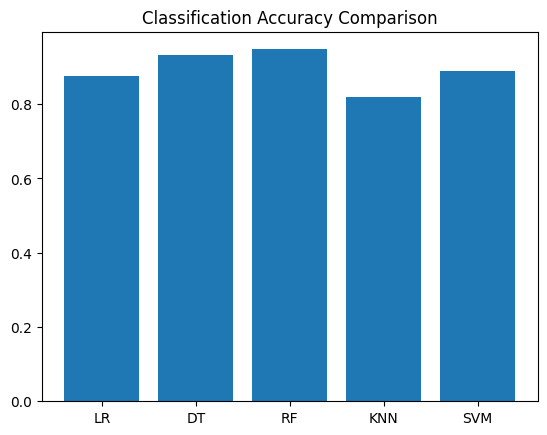

In [16]:
acc = {
    "LR": accuracy_score(y_test, y_pred_lr),
    "DT": accuracy_score(y_test, y_pred_dt),
    "RF": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "SVM": accuracy_score(y_test, y_pred_svm),
}

plt.bar(acc.keys(), acc.values())
plt.title("Classification Accuracy Comparison")
plt.show()

# REGRESSION SECTION

# 1. Regression Models

In [17]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

models = {
    "Linear": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

for name, model in models.items():
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)

    print("\n", name)
    print("MSE:", mean_squared_error(y_test_r, y_pred))
    print("R2:", r2_score(y_test_r, y_pred))


 Linear
MSE: 2.7232254104171254
R2: 0.26263286684867526

 Decision Tree
MSE: 0.8676122931442081
R2: 0.7650768141207235

 Random Forest
MSE: 0.39960401891252956
R2: 0.891799309490085

 KNN
MSE: 1.524255319148936
R2: 0.5872777293528002

 SVR
MSE: 1.44528031026855
R2: 0.6086617747814197


# CLUSTERING SECTION

# 1. Clustering

In [19]:
kmeans = KMeans(n_clusters=5)
k_labels = kmeans.fit_predict(X_scaled)
print("KMeans Silhouette:", silhouette_score(X_scaled, k_labels))

hc = AgglomerativeClustering(n_clusters=5)
h_labels = hc.fit_predict(X_scaled)
print("Hierarchical Silhouette:", silhouette_score(X_scaled, h_labels))

db = DBSCAN()
d_labels = db.fit_predict(X_scaled)

if len(set(d_labels)) > 1:
    print("DBSCAN Silhouette:", silhouette_score(X_scaled, d_labels))
else:
    print("DBSCAN failed to form clusters")

KMeans Silhouette: 0.11869980706869142
Hierarchical Silhouette: 0.144543233493771
DBSCAN Silhouette: -0.21946281135816306


# 2. Feature Importance

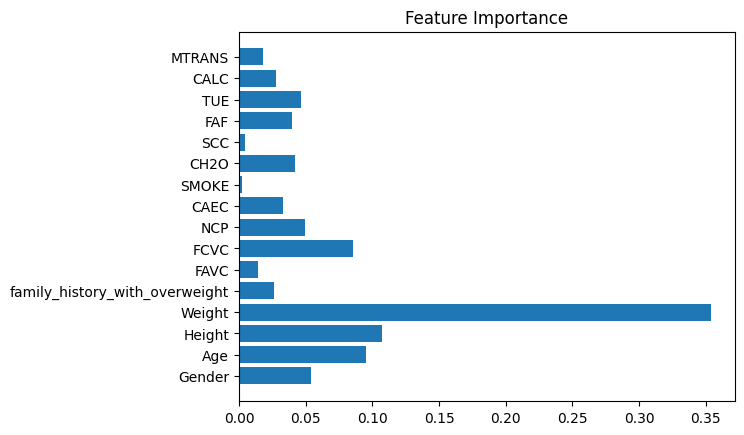

In [20]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importance = rf.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()